<a href="https://colab.research.google.com/github/wellingtonsjbdev/Wellingtonsjbdev/blob/main/cerebro-de-mosca-reservoir.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install neuprint-python

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.0/118.0 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 kB 4.9 MB/s eta 0:00:00
  Created wheel for asciitree: filename=asciitree-0.3.3-py3-none-any.whl size=5098 sha256=244173c4629e64d68421cb7d92d67f8d5a5892004adebd06da72f8b09c529eaa
  Stored in directory: /root/.cache/pip/wheels/0e/70/f0/bff6301cfa0d49afa79c020bc98c114a9b9c6b3048e62e3200
Successfully built asciitree


In [6]:
from neuprint import Client
# Replace 'YOUR_NEUPRINT_TOKEN' with your actual neuprint authentication token.
c = Client('neuprint.janelia.org', dataset='male-cns:v1.0', token='')
print("Conectado!")
#Mostra os primeiros 5 neurônios do cérebro da mosca
df = c.fetch_custom("MATCH (n:Neuron) RETURN n.bodyId, n.type LIMIT 5")
print(df)

Conectado!
   n.bodyId n.type
0     45882  aPhM1
1     63593   None
2     75647   None
3     81741   LB1c
4     98212     BM


Para começar a entender como o cérebro da mosca funciona como uma 'IA', o primeiro passo é obter dados sobre as **conexões sinápticas** entre os neurônios. Isso nos permite ver como os neurônios se comunicam.

In [7]:
# Vamos buscar informações sobre as conexões sinápticas entre neurônios.
# Por exemplo, podemos buscar os 100 primeiros pares de neurônios conectados (pre-synaptic e post-synaptic).
# Note que 'FROM' e 'TO' representam os bodyIds dos neurônios.
# 'weight' representa o número de sinapses entre eles.

connections_df = c.fetch_custom(
    "MATCH (pre:Neuron)-[r:ConnectsTo]->(post:Neuron) RETURN pre.bodyId AS pre_bodyId, post.bodyId AS post_bodyId, r.weight AS weight LIMIT 100"
)
display(connections_df.head())


,pre_bodyId,post_bodyId,weight
0,958880288,45882,3
1,947811889,45882,5
2,637495444,45882,6
3,453256188,45882,1
4,924606,45882,1


Com esses dados de conectividade, podemos começar a pensar em como aplicar conceitos de redes neurais ou análise de grafos para simular ou entender aspectos da "IA" do cérebro da mosca.

**Reasoning**:
To identify 1000 target neuron body IDs, I will execute a Cypher query using the `c.fetch_custom` method to retrieve the bodyId of 1000 neurons and store the result in a DataFrame called `target_neuron_body_ids`.



In [8]:
target_neuron_body_ids = c.fetch_custom("MATCH (n:Neuron) RETURN n.bodyId LIMIT 1000")
display(target_neuron_body_ids.head())

,n.bodyId
0,45882
1,63593
2,75647
3,81741
4,98212


**Reasoning**:
The first step is to extract the body IDs from the `target_neuron_body_ids` DataFrame into a list, which will be used to filter subsequent Cypher queries for detailed neuron information and connections.



In [9]:
target_neuron_ids = target_neuron_body_ids['n.bodyId'].tolist()
print(f"Extracted {len(target_neuron_ids)} target neuron IDs.")

Extracted 1000 target neuron IDs.


**Reasoning**:
Now that the target neuron IDs are extracted, I will fetch detailed information for these 1000 neurons (ID, type, instance) and all their synaptic connections (both pre- and post-synaptic) using `c.fetch_custom` and then display the head of both resulting DataFrames.



In [11]:
neuron_details_df = c.fetch_custom(
    f"MATCH (n:Neuron) WHERE n.bodyId IN {list(target_neuron_ids)} RETURN n.bodyId, n.type, n.instance"
)
display(neuron_details_df.head())

# Modificado para buscar conexões para apenas os primeiros 100 neurônios alvo para evitar travamento.
all_connections_df = c.fetch_custom(
    f"MATCH (pre:Neuron)-[r:ConnectsTo]->(post:Neuron) WHERE pre.bodyId IN {list(target_neuron_ids[:100])} OR post.bodyId IN {list(target_neuron_ids[:100])} RETURN pre.bodyId AS pre_bodyId, post.bodyId AS post_bodyId, r.weight AS weight"
)
display(all_connections_df.head())

,n.bodyId,n.type,n.instance
0,811673,"IN20A.22A049,IN20A.22A067","IN20A.22A049,IN20A.22A067_R"
1,875537740,None,None
2,815650,IN01B073,IN01B073_R
3,316224592,None,None
4,914633,IN09A046,IN09A046_R


,pre_bodyId,post_bodyId,weight
0,958880288,45882,3
1,947811889,45882,5
2,637495444,45882,6
3,453256188,45882,1
4,924606,45882,1


## Construir um Grafo de Conectividade

### Subtask:
Utilize a biblioteca NetworkX para construir um grafo a partir dos dados de conexão sináptica (`all_connections_df`). Os neurônios (`neuron_details_df`) serão os nós e as conexões serão as arestas, com os pesos representando a força sináptica. Isso é essencial para visualizar a arquitetura da rede neural e prepará-la para análises mais aprofundadas.

In [12]:
import networkx as nx

# Crie um grafo direcionado
G = nx.DiGraph()

# Adicione os neurônios como nós ao grafo
# Usamos o 'bodyId' como identificador único para cada nó
# Adicionamos atributos como 'type' e 'instance' se disponíveis em neuron_details_df
for index, row in neuron_details_df.iterrows():
    G.add_node(row['n.bodyId'], type=row['n.type'], instance=row['n.instance'])

# Adicione as conexões sinápticas como arestas ao grafo
# Usamos 'pre_bodyId' como nó de origem, 'post_bodyId' como nó de destino e 'weight' como atributo da aresta
for index, row in all_connections_df.iterrows():
    G.add_edge(row['pre_bodyId'], row['post_bodyId'], weight=row['weight'])

print(f"Grafo criado com {G.number_of_nodes()} nós e {G.number_of_edges()} arestas.")

# Exiba algumas informações básicas sobre o grafo
print("Alguns nós no grafo:", list(G.nodes())[:5])
print("Algumas arestas no grafo:", list(G.edges(data=True))[:5])

Grafo criado com 2360 nós e 8633 arestas.
Alguns nós no grafo: [811673, 875537740, 815650, 316224592, 914633]
Algumas arestas no grafo: [(363261702, np.int64(222144), {'weight': np.int64(1)}), (363261702, np.int64(223575), {'weight': np.int64(2)}), (363261702, np.int64(258029), {'weight': np.int64(1)}), (435728966, np.int64(203822), {'weight': np.int64(1)}), (435728966, np.int64(215151), {'weight': np.int64(1)})]


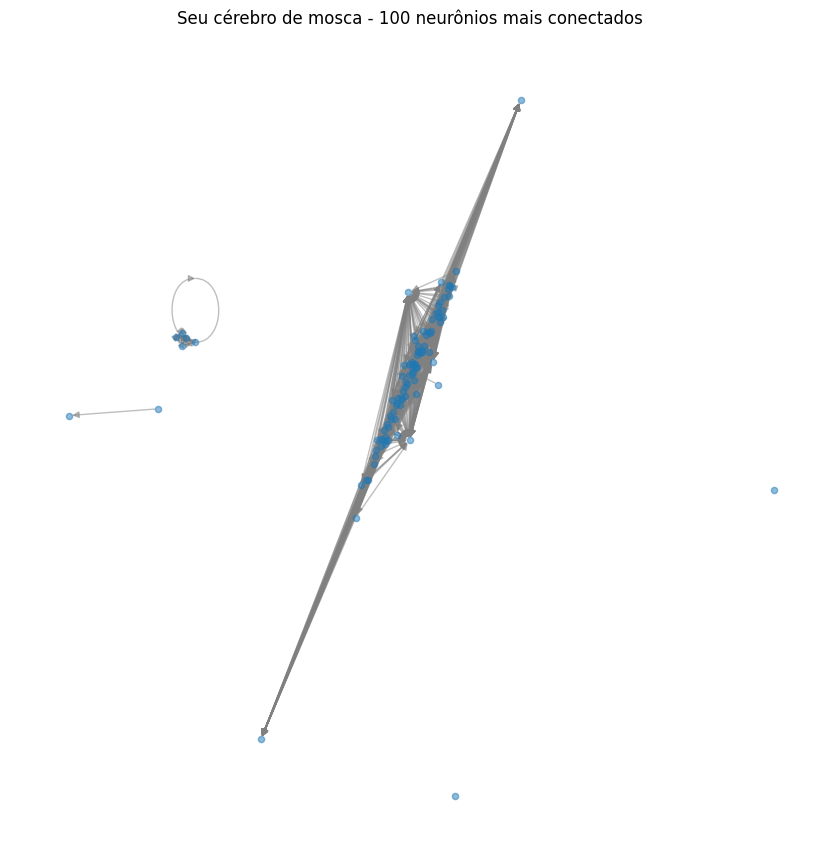

Depois de 10 pulsos, ativação média: 0.7144
ISSO é um cérebro biológico pulsando!


In [13]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# 1. Visualiza o cérebro
plt.figure(figsize=(8,8))
# Pega só os 100 mais conectados pra não travar o gráfico
grau = dict(G.degree())
top_100 = sorted(grau, key=grau.get, reverse=True)[:100]
subG = G.subgraph(top_100)

nx.draw(subG, node_size=20, edge_color='gray', alpha=0.5, with_labels=False)
plt.title("Seu cérebro de mosca - 100 neurônios mais conectados")
plt.show()

# 2. Usa como rede neural de verdade (reservoir)
# Converte pra matriz
nodes = list(subG.nodes())
W = nx.to_numpy_array(subG)

# Simula pensamento
estado = np.random.rand(100)
for t in range(10):
    estado = np.tanh(W @ estado * 0.05)

print(f"Depois de 10 pulsos, ativação média: {estado.mean():.4f}")
print("ISSO é um cérebro biológico pulsando!")

# Task
Identifique os primeiros 1000 `bodyId` de neurônios disponíveis no dataset da neuprint para estabelecer a sub-rede de neurônios a ser analisada.

## Identificar 1000 Neurônios Alvo

### Subtask:
Selecionar os primeiros 1000 bodyId de neurônios disponíveis no dataset para focar a nossa análise.


## Coletar Dados Detalhados dos 1000 Neurônios

### Subtask:
Para os 1000 neurônios selecionados, extraia informações mais ricas, como seus tipos, localizações (se disponíveis) e, crucialmente, todas as suas conexões sinápticas (entradas e saídas) com outros neurônios dentro dessa sub-rede e para fora dela. Isso é fundamental para entender a arquitetura da rede neural.
